In [136]:
#!pip install xgboost

In [137]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier 
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [138]:
# Carregando dados 
url = "https://raw.githubusercontent.com/vbomura/tc5/main/Codigos/base_anos_limpo.xlsx"
dfBaseAnosLimpos = pd.read_excel(url)

In [139]:
# Definição das colunas de entrada (features) e do alvo (target)
#features = ['ian', 'ida', 'ieg', 'iaa', 'ips', 'ipp', 'ipv']
#features = ['idade','ian', 'ida', 'ieg', 'ipp', 'ipv']
features = ['idade','ian', 'ida', 'ieg', 'ipv']
target = 'defasagem'

In [140]:
dfBaseAnosLimpos

,ra,fase,turma,nome_anonimizado,ano_nasc_original,idade_original,genero,ano_ingresso,instituicao_de_ensino,pedra,...,ipv,ian,fase_ideal_original,defasagem,ano_aba,ano_nascimento,fase_ideal,ipp,fase_original,idade
0,RA-1,7,A,Aluno-1,2003,19,Feminino,2016,Escola Pública,Quartzo,...,7.278,5.0,Fase 8 (Universitários),-1,2022,2003,FASE 8,NaN,NaN,19
1,RA-2,7,A,Aluno-2,2005,17,Feminino,2017,Rede Decisão,Ametista,...,6.778,10.0,Fase 7 (3º EM),0,2022,2005,FASE 7,NaN,NaN,17
2,RA-3,7,A,Aluno-3,2005,17,Feminino,2016,Rede Decisão,Ágata,...,7.556,10.0,Fase 7 (3º EM),0,2022,2005,FASE 7,NaN,NaN,17
3,RA-4,7,A,Aluno-4,2005,17,Masculino,2017,Rede Decisão,Quartzo,...,5.278,10.0,Fase 7 (3º EM),0,2022,2005,FASE 7,NaN,NaN,17
4,RA-5,7,A,Aluno-5,2005,17,Feminino,2016,Rede Decisão,Ametista,...,7.389,10.0,Fase 7 (3º EM),0,2022,2005,FASE 7,NaN,NaN,17
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2840,RA-291,FASE 7,7E,Aluno-291,2009-01-17 00:00:00,15,Masculino,2022,Privada - Programa de Apadrinhamento,Ametista,...,7.500,10.0,Fase 5 (1° EM),2,2024,2009,FASE 5,7.5,7E,15
2841,RA-86,FASE 7,7E,Aluno-86,2006-10-04 00:00:00,18,Masculino,2021,Privada *Parcerias com Bolsa 100%,Ametista,...,7.500,10.0,Fase 7 (3° EM),0,2024,2006,FASE 7,7.5,7E,18
2842,RA-143,FASE 7,7E,Aluno-143,2009-08-01 00:00:00,15,Masculino,2021,Privada - Programa de Apadrinhamento,Ametista,...,7.500,10.0,Fase 5 (1° EM),2,2024,2009,FASE 5,7.5,7E,15
2843,RA-166,FASE 7,7E,Aluno-166,2008-06-03 00:00:00,16,Masculino,2021,Privada *Parcerias com Bolsa 100%,Topázio,...,7.500,10.0,Fase 6 (2° EM),1,2024,2008,FASE 6,7.5,7E,16


In [150]:
# Calculate the median of each numeric column
medians_by_column = dfBaseAnosLimpos[features].median()

print("\nMedians by Column:")
print(medians_by_column)


Medians by Column:
idade    12.000000
ian       5.000000
ida       6.666667
ieg       8.654244
ipv       7.583000
dtype: float64


In [151]:
print(dfBaseAnosLimpos[features].describe())

             idade          ian          ida          ieg          ipv
count  2845.000000  2845.000000  2845.000000  2845.000000  2845.000000
mean     12.164851     7.010545     6.376784     8.229802     7.545910
std       2.761989     2.510504     1.957528     1.568487     1.085439
min       7.000000     2.500000     0.000000     0.000000     2.500000
25%      10.000000     5.000000     5.100000     7.500000     6.966000
50%      12.000000     5.000000     6.666667     8.654244     7.583000
75%      14.000000    10.000000     7.833333     9.400000     8.255000
max      22.000000    10.000000    10.000000    10.000000    10.010000


In [141]:
# Verificando se existem valores nulos e removendo-os
df_model = dfBaseAnosLimpos[features + [target]].dropna()

df_model

,idade,ian,ida,ieg,ipv,defasagem
0,19,5.0,4.000000,4.100000,7.278,-1
1,17,10.0,6.800000,5.200000,6.778,0
2,17,10.0,5.600000,7.900000,7.556,0
3,17,10.0,5.000000,4.500000,5.278,0
4,17,10.0,5.200000,8.600000,7.389,0
...,...,...,...,...,...,...
2840,15,10.0,6.166667,9.737667,7.500,2
2841,18,10.0,5.483333,9.704333,7.500,0
2842,15,10.0,2.633333,9.920000,7.500,2
2843,16,10.0,8.266667,9.246000,7.500,1


In [142]:
X = df_model[features]
y = df_model[target]

# Separando em treino/teste 20%
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [143]:
# Instanciando o modelo
# max_iter=1000 garante que o modelo tenha tentativas suficientes para convergir em dados complexos
log_model = LogisticRegression(max_iter=1000, random_state=42)

# Treinando
log_model.fit(X_train, y_train)

# Prevendo
y_pred_log = log_model.predict(X_test)

# Avaliando
print("--- Regressão Logística ---")
print(f"Acurácia: {accuracy_score(y_test, y_pred_log):.2%}\n")
print(classification_report(y_test, y_pred_log))

--- Regressão Logística ---
Acurácia: 80.14%

              precision    recall  f1-score   support

          -4       0.00      0.00      0.00         1
          -3       0.89      1.00      0.94         8
          -2       0.00      0.00      0.00        80
          -1       0.75      1.00      0.86       243
           0       0.86      1.00      0.93       205
           1       0.00      0.00      0.00        27
           2       0.00      0.00      0.00         4
           3       0.00      0.00      0.00         1

    accuracy                           0.80       569
   macro avg       0.31      0.38      0.34       569
weighted avg       0.65      0.80      0.71       569



In [144]:
# 1. Preparação dos dados com LabelEncoder (A CORREÇÃO ESTÁ AQUI)
le = LabelEncoder()
y_encoded = le.fit_transform(y) # Transforma [-4, -3...] em [0, 1...]

# Refazendo o split com o y_encoded
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.3, random_state=42)

# 2. Instanciando o modelo
# Removemos use_label_encoder=False pois já codificamos manualmente acima
# 'mlogloss' é melhor para multiclasse (várias categorias de defasagem)
xgb_model = XGBClassifier(eval_metric='mlogloss', random_state=42)

# 3. Treinando
xgb_model.fit(X_train, y_train)

# 4. Prevendo
y_pred_xgb = xgb_model.predict(X_test)

# 5. Avaliando (Traduzindo de volta para os números originais para o print fazer sentido)
y_test_original = le.inverse_transform(y_test)
y_pred_original = le.inverse_transform(y_pred_xgb)

print("--- XGBoost ---")
print(f"Acurácia: {accuracy_score(y_test_original, y_pred_original):.2%}\n")
print(classification_report(y_test_original, y_pred_original))

--- XGBoost ---
Acurácia: 79.16%

              precision    recall  f1-score   support

          -4       0.00      0.00      0.00         1
          -3       0.93      1.00      0.96        13
          -2       0.42      0.24      0.31       123
          -1       0.78      0.88      0.83       365
           0       0.89      0.99      0.94       308
           1       0.43      0.08      0.14        37
           2       0.75      0.50      0.60         6
           3       0.00      0.00      0.00         1

    accuracy                           0.79       854
   macro avg       0.52      0.46      0.47       854
weighted avg       0.75      0.79      0.76       854



In [145]:



model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("\n--- Relatório de Classificação ---")
print(classification_report(y_test, y_pred))

print("\n--- Acurácia ---")
print(f"{accuracy_score(y_test, y_pred):.2%}")


--- Relatório de Classificação ---
              precision    recall  f1-score   support

           1       0.00      0.00      0.00         1
           2       0.93      1.00      0.96        13
           3       0.47      0.21      0.29       123
           4       0.78      0.92      0.84       365
           5       0.88      0.99      0.93       308
           6       0.20      0.03      0.05        37
           7       1.00      0.33      0.50         6
           8       0.00      0.00      0.00         1

    accuracy                           0.80       854
   macro avg       0.53      0.43      0.45       854
weighted avg       0.75      0.80      0.76       854


--- Acurácia ---
79.86%


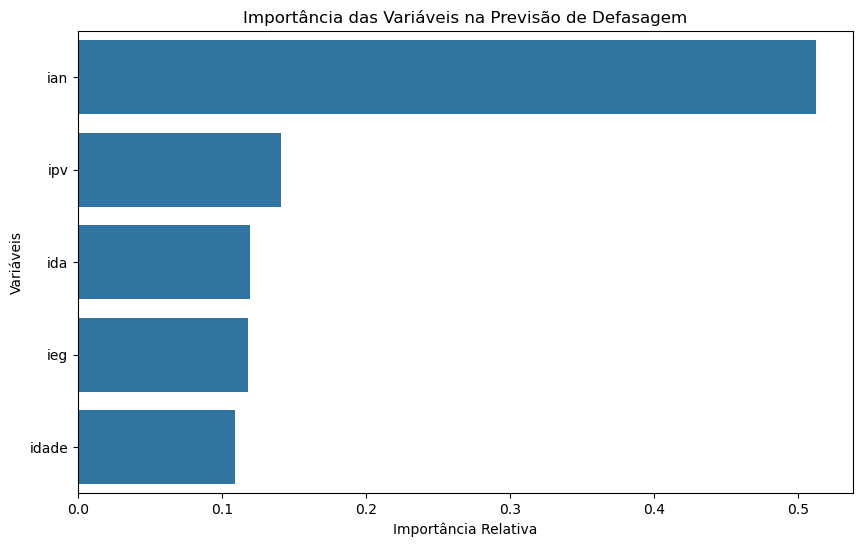

In [146]:
#Visualização da Importância das Variáveis no RandomForestClassifier
feature_importances = pd.Series(model.feature_importances_, index=features).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=feature_importances, y=feature_importances.index)
plt.title('Importância das Variáveis na Previsão de Defasagem')
plt.xlabel('Importância Relativa')
plt.ylabel('Variáveis')
plt.show()

In [147]:
import joblib
#Criando joblib da predição
#joblib.dump(model,'RandomForest.joblib')